# LAB 3 : Word embeddings and TF-IDF

## Exercise 01 : Word Embedding

In [72]:
import gensim
from gensim.models import Word2Vec

print(gensim.__version__)

4.3.2


In gensim we have : 
- FastText
- Word2Vec
- Glove
- COnceptNet

In [73]:
import gensim.downloader as api

available_models = list(api.info()["models"].keys())
print(f"Available models \n{'='*30}")
for model in available_models:
    print(model)

Available models 
fasttext-wiki-news-subwords-300
conceptnet-numberbatch-17-06-300
word2vec-ruscorpora-300
word2vec-google-news-300
glove-wiki-gigaword-50
glove-wiki-gigaword-100
glove-wiki-gigaword-200
glove-wiki-gigaword-300
glove-twitter-25
glove-twitter-50
glove-twitter-100
glove-twitter-200
__testing_word2vec-matrix-synopsis


In [74]:
# model = api.load('word2vec-google-news-300')
model = api.load("glove-twitter-100")
model.save("glove-twitter-100.model")
print("model saved successfully!")

KeyboardInterrupt: 

In [75]:
from gensim.models import KeyedVectors

# Load the saved model
# model = KeyedVectors.load('glove-twitter-25.model')
model = KeyedVectors.load("glove-twitter-100.model")

In [76]:
from gensim.test.utils import common_texts

print(common_texts)

[['human', 'interface', 'computer'], ['survey', 'user', 'computer', 'system', 'response', 'time'], ['eps', 'user', 'interface', 'system'], ['system', 'human', 'system', 'eps'], ['user', 'response', 'time'], ['trees'], ['graph', 'trees'], ['graph', 'minors', 'trees'], ['graph', 'minors', 'survey']]


In [77]:
vector_king = model["king"]
print(vector_king)

[-3.7500e-01 -2.7532e-01  1.2489e-01 -9.2143e-02 -4.3104e-01  2.5268e-02
 -4.1867e-02  1.2848e-01 -7.9363e-02 -1.0011e-01  1.4076e-01  1.0922e-01
 -3.4546e+00 -6.9851e-01  6.6580e-01  5.1494e-01  4.5912e-01 -2.1957e-01
  4.4094e-01 -3.0631e-01  1.2293e-01 -9.9830e-02 -2.5755e-01 -6.1872e-01
  1.0613e+00 -9.4278e-01  1.9284e-01 -8.2089e-02  2.7782e-01 -1.8595e-01
  2.9140e-02 -3.0870e-01 -3.9870e-01 -4.3038e-01  3.8403e-01  3.3243e-01
 -1.4446e-01  1.6682e-01  4.2301e-01 -2.6490e-01 -7.8106e-02 -4.6756e-01
 -3.4039e-01 -1.3690e-01  7.0890e-01 -4.8015e-01  8.9183e-02 -2.3709e-01
  7.5124e-01  2.0507e-01 -5.5263e-01 -3.8105e-01 -7.7082e-02  3.6118e-01
 -8.9840e-01 -5.3537e-01  3.3161e-01 -1.3460e-01 -5.7742e-02  1.9428e-01
  1.8008e-01 -4.0697e-01  2.6654e-03 -7.8771e-02 -2.3616e-01 -9.8115e-01
 -1.6823e-01  1.1459e-01 -2.7011e-01 -2.1435e-02  2.3491e-01 -1.1341e+00
 -3.3837e-01  1.6548e-01  5.3073e-01 -3.0098e-01 -3.6769e-01  4.2092e-01
  1.4201e-01  1.7346e-02  7.8406e-01  3.1441e-01 -1

In [78]:
vector_king.shape

(100,)

In [79]:
similar_words = model.most_similar("king")
for sim_word in similar_words:
    print(sim_word)

('prince', 0.7755852937698364)
('aka', 0.7499572038650513)
('queen', 0.7075933814048767)
('the', 0.6970062851905823)
('mr.', 0.6886698007583618)
('legend', 0.6823233366012573)
("'s", 0.6767037510871887)
('kings', 0.6758018732070923)
('jack', 0.6584787964820862)
('royal', 0.6550301313400269)


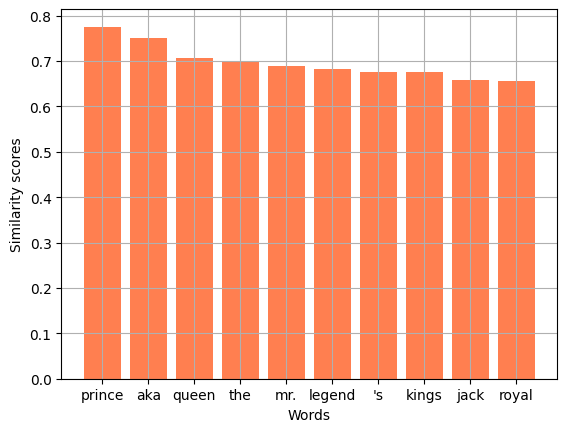

In [80]:
# plot the most similar words
import matplotlib.pyplot as plt

similar_words = model.most_similar("king")
words = [word[0] for word in similar_words]
values = [word[1] for word in similar_words]
plt.bar(words, values, color="coral")
plt.grid(True)
plt.xlabel("Words")
plt.ylabel("Similarity scores")
plt.show()

In [81]:
similarity = model.similarity("king", "queen")
print(f"Similarity between 'King' and 'Queen': {similarity}")

Similarity between 'King' and 'Queen': 0.7075933814048767


In [82]:
analogy = model.most_similar(positive=["king", "woman"], negative=["man"])
print(analogy)

[('queen', 0.7052316069602966), ('prince', 0.6666139364242554), ('mother', 0.6436765193939209), ('royal', 0.6417251229286194), ('father', 0.5952690243721008), ('african', 0.5883978009223938), ('princess', 0.588217556476593), ('called', 0.5842776894569397), ('meets', 0.584027886390686), ('american', 0.5815179944038391)]


In [83]:
# Correcting the analogy to be clearer
analogy = model.most_similar(positive=["potato", "fruits"], negative=["apple"])

print(analogy)

[('vegetables', 0.6845729947090149), ('potatoes', 0.6757118701934814), ('garlic', 0.6482212543487549), ('salad', 0.6387143731117249), ('veggies', 0.6346180438995361), ('tofu', 0.6165464520454407), ('vegetable', 0.6155366897583008), ('broccoli', 0.6102173924446106), ('lettuce', 0.6091275811195374), ('beans', 0.6071915030479431)]


In [84]:
from gensim.models import Word2Vec

sentences = [
    ["king", "queen", "man", "woman"],
    ["king", "monarch", "prince", "queen"],
    ["man", "woman", "child", "family"],
]

In [85]:
model_custom = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

In [86]:
vector_king_custom = model_custom.wv["king"]
print(vector_king_custom)

[-5.3622725e-04  2.3643136e-04  5.1033497e-03  9.0092728e-03
 -9.3029495e-03 -7.1168090e-03  6.4588725e-03  8.9729885e-03
 -5.0154282e-03 -3.7633716e-03  7.3805046e-03 -1.5334714e-03
 -4.5366134e-03  6.5540518e-03 -4.8601604e-03 -1.8160177e-03
  2.8765798e-03  9.9187379e-04 -8.2852151e-03 -9.4488179e-03
  7.3117660e-03  5.0702621e-03  6.7576934e-03  7.6286553e-04
  6.3508903e-03 -3.4053659e-03 -9.4640139e-04  5.7685734e-03
 -7.5216377e-03 -3.9361035e-03 -7.5115822e-03 -9.3004224e-04
  9.5381187e-03 -7.3191668e-03 -2.3337686e-03 -1.9377411e-03
  8.0774371e-03 -5.9308959e-03  4.5162440e-05 -4.7537340e-03
 -9.6035507e-03  5.0072931e-03 -8.7595852e-03 -4.3918253e-03
 -3.5099984e-05 -2.9618145e-04 -7.6612402e-03  9.6147433e-03
  4.9820580e-03  9.2331432e-03 -8.1579173e-03  4.4957981e-03
 -4.1370760e-03  8.2453608e-04  8.4986202e-03 -4.4621765e-03
  4.5175003e-03 -6.7869602e-03 -3.5484887e-03  9.3985079e-03
 -1.5776526e-03  3.2137157e-04 -4.1406299e-03 -7.6826881e-03
 -1.5080082e-03  2.46979

In [87]:
similar_words_custom = model_custom.wv.most_similar("king")
print(similar_words_custom)

[('family', 0.09291722625494003), ('child', 0.016134677454829216), ('queen', -0.01083916611969471), ('monarch', -0.027750369161367416), ('man', -0.05234673246741295), ('prince', -0.059876296669244766), ('woman', -0.111670583486557)]


In [88]:
similarity_custom = model_custom.wv.similarity("king", "queen")
print(f"Custom model similarity between 'King' and 'Queen': {similarity_custom}")

Custom model similarity between 'King' and 'Queen': -0.010839165188372135


In [89]:
analogy_custom = model_custom.wv.most_similar(
    positive=["king", "woman"], negative=["man"]
)
print(analogy_custom[0])

('family', 0.048077620565891266)


## Comparison Between Word2Vec, GloVe, and FastText

| Feature              | Word2Vec                                      | GloVe                                          | FastText                                      |
|----------------------|-----------------------------------------------|-----------------------------------------------|-----------------------------------------------|
| **Model Type**        | Predictive (based on context windows)         | Count-based (factorizes co-occurrence matrix) | Predictive (includes subword information)     |
| **Training Approach** | Uses skip-gram or CBOW to predict words       | Uses matrix factorization on co-occurrence data| Uses skip-gram but also considers subword units|
| **Subword Information** | No                                          | No                                            | Yes (can handle unseen words by breaking them into character n-grams) |
| **Output**            | Word vectors                                 | Word vectors                                 | Word vectors (and subword vectors)            |
| **Advantages**        | Efficient, captures word context well        | Can handle large vocabularies, pre-trained models like GloVe are widely available | Handles out-of-vocabulary (OOV) words, better for morphologically rich languages |
| **Disadvantages**     | Cannot handle OOV words                      | No subword information, cannot handle OOV words | Computationally more expensive due to subword modeling |
| **Use Cases**         | General word embedding tasks                 | Pre-trained embeddings for tasks like sentiment analysis | Handling rare words, morphologically rich languages, OOV words |


## Exercise 02 : TF-IDF